In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [35]:
df = pd.read_csv("powerdemand-prediction/EDA/demand_celcius.csv", index_col="일시")
df.drop("Unnamed: 0", axis=1, inplace=True)

df.index = pd.to_datetime(df.index)

In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 51144 entries, 2019-01-01 00:00:00 to 2024-10-31 23:00:00
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   hm                51144 non-null  float64
 1   ta                51144 non-null  float64
 2   power demand(MW)  51144 non-null  float64
dtypes: float64(3)
memory usage: 1.6 MB


In [37]:
df["ymd"] = df.index.strftime("%Y-%m-%d")

In [38]:
# 시간 데이터 -> 일&주&월 데이터로 변환하여 분석한다.
df["year"] = df.index.year
df["month"] = df.index.month

In [39]:
df

,hm,ta,power demand(MW),ymd,year,month
일시,,,,,,
2019-01-01 00:00:00,59.705026,-4.174162,65388.0,2019-01-01,2019,1
2019-01-01 01:00:00,60.096649,-4.349947,63045.0,2019-01-01,2019,1
2019-01-01 02:00:00,61.854850,-4.491993,61036.0,2019-01-01,2019,1
2019-01-01 03:00:00,63.020635,-4.648325,59834.0,2019-01-01,2019,1
2019-01-01 04:00:00,63.784303,-4.722354,59491.0,2019-01-01,2019,1
...,...,...,...,...,...,...
2024-10-31 19:00:00,75.547619,15.667637,67551.0,2024-10-31,2024,10
2024-10-31 20:00:00,79.587125,14.787954,65341.0,2024-10-31,2024,10
2024-10-31 21:00:00,82.265079,14.053263,63341.0,2024-10-31,2024,10


In [61]:
# 
df["ymd"] = pd.to_datetime(df["ymd"])
df_year = df.groupby("ymd")["power demand(MW)"].mean()

# 주별
weekly_df = df.resample('W').mean()  # 또는 .sum(), .max(), .min() 가능

# 월별
monthly_df = df.resample('ME').mean()  # 또는 .sum(), .max(), .min() 가능

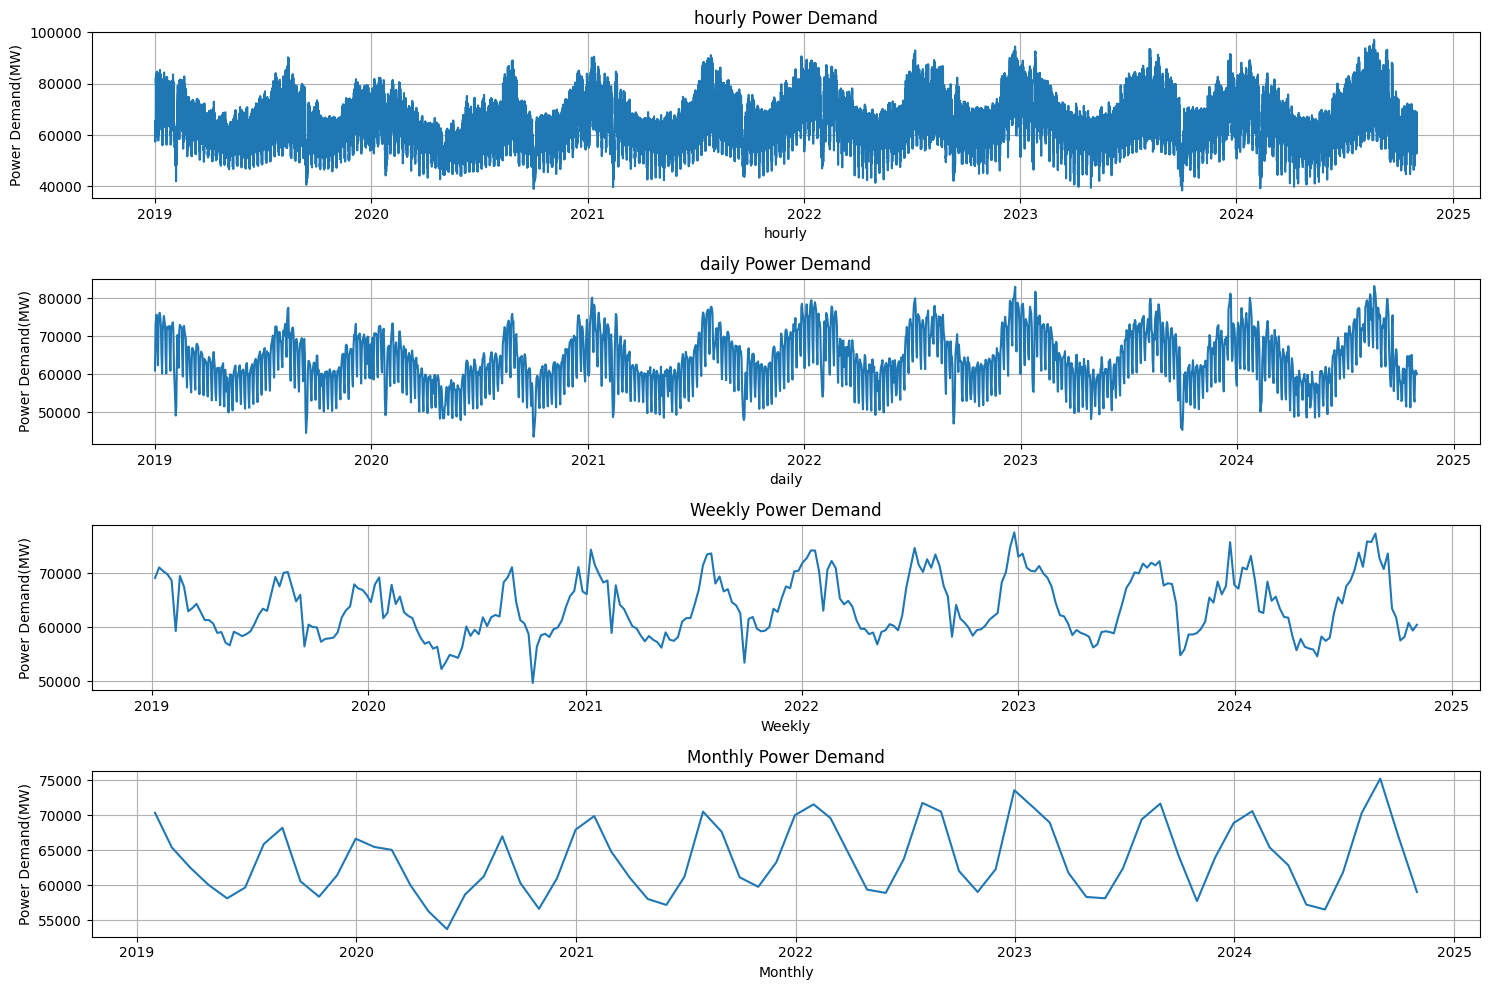

In [64]:
# 서브플롯 생성실시
fig, axs = plt.subplots(4, 1, figsize=(15, 10))

# 서브 플롯 양식 
axs[0].plot(df["power demand(MW)"])
axs[0].set_title("hourly Power Demand")
axs[0].set_xlabel("hourly")
axs[0].set_ylabel("Power Demand(MW)")
axs[0].grid(True)

axs[1].plot(df_year)
axs[1].set_title("daily Power Demand")
axs[1].set_xlabel("daily")
axs[1].set_ylabel("Power Demand(MW)")
axs[1].grid(True)

axs[2].plot(weekly_df["power demand(MW)"])
axs[2].set_title("Weekly Power Demand")
axs[2].set_xlabel("Weekly")
axs[2].set_ylabel("Power Demand(MW)")
axs[2].grid(True)

axs[3].plot(monthly_df["power demand(MW)"])
axs[3].set_title("Monthly Power Demand")
axs[3].set_xlabel("Monthly")
axs[3].set_ylabel("Power Demand(MW)")
axs[3].grid(True)

plt.tight_layout()